In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray as rxr
from rasterio.features import shapes
from shapely.geometry import shape
import numpy as np
from scipy.spatial import KDTree
from scipy.stats import norm

In [2]:
samples_gdf = gpd.read_parquet('../data/sampling/samples.par')
samples_gdf = samples_gdf.loc[samples_gdf['split'].isin(['train', 'val', 'test'])].centroid

ms_nlcd = rxr.open_rasterio('../data/sampling/NLCD/NLCD_MS_MSTM.tif').isel(band=0)

# get data footprint into geodataframe
mask = ms_nlcd != ms_nlcd.rio.nodata
shapes_gen = shapes(mask.data.astype('uint8'), mask=mask, transform=ms_nlcd.rio.transform())
geoms = [shape(geom) for geom, value in shapes_gen if value == 1]
footprint_gdf = gpd.GeoDataFrame(geometry=geoms, crs=ms_nlcd.rio.crs).dissolve().to_crs(samples_gdf.crs)


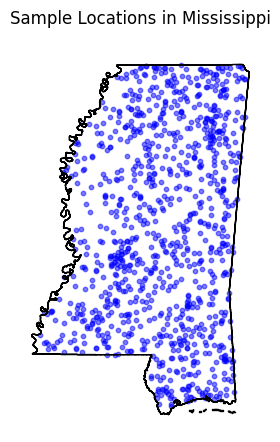

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
footprint_gdf.boundary.plot(ax=ax, color='black', linewidth=1)
samples_gdf.plot(ax=ax, markersize=10, color='blue', alpha=0.5)
ax.set_title('Sample Locations in Mississippi')
ax.axis('off')

plt.show()

In [4]:
def analyze_ann_irregular(points, polygon_aoi, edge_correction=True):
    """
    Calculates ANN with optional Donnelly's Edge Correction.
    """
    n = len(points)
    area = polygon_aoi.area
    
    # 1. Observed Mean Distance
    tree = KDTree(points)
    distances, _ = tree.query(points, k=2)
    d_obs = np.mean(distances[:, 1])
    
    # 2. Expected Mean Distance
    density = n / area
    d_exp = 0.5 / np.sqrt(density)
    
    # Apply Donnelly's edge correction if requested
    if edge_correction:
        perimeter = polygon_aoi.length
        d_exp += 0.0514 * perimeter / n
    
    # 3. R Ratio
    R = d_obs / d_exp
    
    # 4. Z-Score and P-Value
    se = 0.26136 / np.sqrt(n * density)
    z_score = (d_obs - d_exp) / se
    p_value = 2 * (1 - norm.cdf(abs(z_score)))
    
    return {
        "R_ratio": R,
        "z_score": z_score,
        "observed_mean_dist": d_obs,
        "expected_mean_dist": d_exp,
        "p_value": p_value
    }

# Run with edge correction
results = analyze_ann_irregular(
    points=np.array([(pt.x, pt.y) for pt in samples_gdf]),
    polygon_aoi=footprint_gdf.union_all(),
    edge_correction=True
)
print(f"R Ratio: {results['R_ratio']:.4f}")
print(f"Z-Score: {results['z_score']:.4f}")
print(f"Observed Mean Distance: {results['observed_mean_dist']:.4f}")
print(f"Expected Mean Distance: {results['expected_mean_dist']:.4f}")
print(f"P-Value: {results['p_value']:.4f}")

R Ratio: 0.9485
Z-Score: -3.2110
Observed Mean Distance: 5439.4690
Expected Mean Distance: 5734.8549
P-Value: 0.0013
